In [ ]:
import os
import json
from langchain_openai import ChatOpenAI,OpenAIEmbeddings
from dotenv import load_dotenv
from llama_parse import LlamaParse
from langchain_core.documents import Document
from langchain_classic.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.tools import tool
from langgraph.graph import StateGraph,START
from typing import TypedDict,Annotated
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage,BaseMessage,SystemMessage
from langgraph.prebuilt import ToolNode,tools_condition
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
load_dotenv()

True

In [3]:
os.environ['LANGCHAIN_PROJECT']='Rag-Proj-Tools'

In [4]:
llm=ChatOpenAI(model='gpt-4o-mini')
embediing_model=OpenAIEmbeddings(model='text-embedding-3-small')

In [5]:

try:
    parser=LlamaParse(
        result_type='markdown',#type:ignore
        api_key=os.getenv('LLAMA_PARSE_KEY')#type:ignore
        )
except Exception as e:
    print("Error is ",e)

In [6]:
llma_docs=parser.load_data('./intro-to-ml.pdf')

Started parsing the file under job_id bd556657-242e-43d3-adff-4aa1a4557bc2


In [7]:
llma_docs

[Document(id_='9feb1772-06a1-41e4-a32e-74a6d83876c7', embedding=None, metadata={}, excluded_embed_metadata_keys=[], excluded_llm_metadata_keys=[], relationships={}, metadata_template='{key}: {value}', metadata_separator='\n', text_resource=MediaResource(embeddings=None, data=None, text="\n\nO'REILLY®\n\n# Introduction to Machine Learning <u>with</u> <u>Python</u>\n\nA GUIDE FOR DATA SCIENTISTS\n\nAndreas C. Müller & Sarah Guido\n", path=None, url=None, mimetype=None), image_resource=None, audio_resource=None, video_resource=None, text_template='{metadata_str}\n\n{content}'),
 Document(id_='881aae3a-906e-42f9-94e8-b8e16ca2dc27', embedding=None, metadata={}, excluded_embed_metadata_keys=[], excluded_llm_metadata_keys=[], relationships={}, metadata_template='{key}: {value}', metadata_separator='\n', text_resource=MediaResource(embeddings=None, data=None, text='\n\n\n# O\'REILLY®\n\n# Introduction to Machine Learning with Python\n\nMachine learning has become an integral part of many comme

In [10]:
data_to_save=[]

for i,doc in enumerate(llma_docs):
    if not doc.metadata:
        metadata={
            'id':doc.id_,
            'pagenumber':i+1,
            'title':'intro-to-ml.pdf',
            'file_path':'./intro-to-ml.pdf'
            }       
    else:
        metadata=doc.metadata  
        
    data_to_save.append({'page_content':doc.text,'metadata':metadata}) 

In [11]:
data_to_save

[{'page_content': "\n\nO'REILLY®\n\n# Introduction to Machine Learning <u>with</u> <u>Python</u>\n\nA GUIDE FOR DATA SCIENTISTS\n\nAndreas C. Müller & Sarah Guido\n",
  'metadata': {'id': '9feb1772-06a1-41e4-a32e-74a6d83876c7',
   'pagenumber': 1,
   'title': 'intro-to-ml.pdf',
   'file_path': './intro-to-ml.pdf'}},
 {'page_content': '\n\n\n# O\'REILLY®\n\n# Introduction to Machine Learning with Python\n\nMachine learning has become an integral part of many commercial applications and research projects, but this field is not exclusive to large companies with extensive research teams. If you use Python, even as a beginner, this book will teach you practical ways to build your own machine learning solutions. With all the data available today, machine learning applications are limited only by your imagination.\n\nYou\'ll learn the steps necessary to create a successful machine learning application with Python and the scikit-learn library. Authors **Andreas Müller** and **Sarah Guido** foc

In [12]:
with open('data-of-book1.json','w',encoding='utf-8') as wr:
    json.dump(data_to_save,wr,ensure_ascii=False,indent=4)

In [13]:
with open("data-of-book1.json", "r",encoding='utf-8') as re:
    docs_book1=json.load(re)

In [14]:
len(docs_book1)

397

In [15]:
documents=[Document(page_content=doc['page_content'],metadata=doc['metadata']) for doc in docs_book1]

In [16]:
splitter=RecursiveCharacterTextSplitter(chunk_size=1000,chunk_overlap=200)

In [17]:
chunks=splitter.split_documents(documents)

In [18]:
chunks

[Document(metadata={'id': '9feb1772-06a1-41e4-a32e-74a6d83876c7', 'pagenumber': 1, 'title': 'intro-to-ml.pdf', 'file_path': './intro-to-ml.pdf'}, page_content="O'REILLY®\n\n# Introduction to Machine Learning <u>with</u> <u>Python</u>\n\nA GUIDE FOR DATA SCIENTISTS\n\nAndreas C. Müller & Sarah Guido"),
 Document(metadata={'id': '881aae3a-906e-42f9-94e8-b8e16ca2dc27', 'pagenumber': 2, 'title': 'intro-to-ml.pdf', 'file_path': './intro-to-ml.pdf'}, page_content="# O'REILLY®\n\n# Introduction to Machine Learning with Python\n\nMachine learning has become an integral part of many commercial applications and research projects, but this field is not exclusive to large companies with extensive research teams. If you use Python, even as a beginner, this book will teach you practical ways to build your own machine learning solutions. With all the data available today, machine learning applications are limited only by your imagination.\n\nYou'll learn the steps necessary to create a successful mac

In [19]:
vector_store=FAISS.from_documents(chunks,embediing_model)

In [20]:
vector_store

In [21]:
retriver=vector_store.as_retriever(search_type='similarity',search_kwargs={'k':4})

In [24]:
retriver.invoke('What is a Decison Tree')[0]

Document(id='e164cbfc-e626-41ec-8bd4-fb958d708d7d', metadata={'id': 'b4c1031f-2f80-4e6f-ae4d-85271b07a720', 'pagenumber': 85, 'title': 'intro-to-ml.pdf', 'file_path': './intro-to-ml.pdf'}, page_content='# **Decision Trees**\n\nDecision trees are widely used models for classification and regression tasks. Essentially, they learn a hierarchy of if/else questions, leading to a decision.\n\nThese questions are similar to the questions you might ask in a game of 20 Questions. Imagine you want to distinguish between the following four animals: bears, hawks, penguins, and dolphins. Your goal is to get to the right answer by asking as few if/else questions as possible. You might start off by asking whether the animal has feathers, a question that narrows down your possible animals to just two. If the answer is "yes," you can ask another question that could help you distinguish between hawks and penguins. For example, you could ask whether the animal can fly. If the animal doesn\'t have feather

In [22]:
@tool
def rag_tool(query):
    """
    Retrive relevant information form the pdf document.
    Use this tool when the user asks factual/conceptual questions
    that might be answered from the stored documents. 
    
    """
    result=retriver.invoke(query)
    
    context=[doc.page_content for doc in result]
    metadata=[doc.metadata for doc in result]
    
    return {
        'query':query,
        'context':context,
        'metadata':metadata
    }
    
    

In [25]:
tools=[rag_tool]
llm_with_tools=llm.bind_tools(tools)

In [26]:
class ChatState(TypedDict):
    messages:Annotated[list[BaseMessage],add_messages]

In [ ]:
def chat_node(state:ChatState):
    messages=state['messages']
    response=llm_with_tools.invoke(messages)
    return {'messages':[response]}

In [28]:
tool_node=ToolNode(tools)

In [33]:
checkpointer=InMemorySaver()
config={'configurable':{'thread_id':'thread_id'}}

In [34]:
graph=StateGraph(ChatState)
graph.add_node('chat_node',chat_node)
graph.add_node('tools',tool_node)

graph.add_edge(START,'chat_node')
graph.add_conditional_edges('chat_node',tools_condition)
graph.add_edge('tools','chat_node')

chatbot=graph.compile(checkpointer=checkpointer)

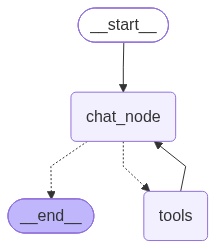

In [35]:
chatbot

In [38]:
result=chatbot.invoke({
    'messages':[
        HumanMessage(
            content="using the pdf,notes,explain how to split a node in decison tree"
            )
        ]
    },
    config=config #type:ignore
    )

In [39]:
print(result['messages'][-1].content)

To split a node in a decision tree, the following procedure is typically followed:

1. **Recursive Partitioning**: The process of splitting nodes is recursive, meaning that at each node, the algorithm assesses the data points currently being considered and chooses an appropriate test to partition this data based on a single feature. This results in the creation of two child nodes for each parent node.

2. **Choosing the Test**:
   - The algorithm evaluates all potential tests on the features (attributes) of the dataset. Each test will assess whether a particular feature value meets a specified condition (e.g., \( x[1] \leq 0.0596 \)).
   - The goal is to choose the test that provides the most information about the target variable. The better the separation of classes (or regression values), the more informative the split.

3. **Creating Child Nodes**:
   - Based on the chosen test, the dataset is split into two groups: those points that satisfy the condition (the left node) and those t